# Decision Trees & Ensemble Basics
### SAME dataset. SAME engineered features. NEW model type.

Yesterday we hit a wall: no amount of feature engineering pushed the *linear* model much further, because a straight line cannot represent interactions and thresholds.

Today we change **only the model**. The data and preprocessing stay identical (we literally reuse the same `ColumnTransformer`). A **Decision Tree** learns rules like *"IF Overall Qual >= 8 AND TotalSF > 2500 THEN high price"* - exactly the interactions and thresholds linear models miss. Then we make trees strong by combining many of them:

- **Decision Tree** - one tree; intuitive but overfits.
- **Random Forest** - hundreds of trees on random subsets, averaged (bagging).
- **Gradient Boosting** - trees added in sequence, each fixing the last one's errors.

> **Point to ponder:** do more powerful models automatically win? Sometimes ensembles break the linear ceiling, but not always.


## 0. Setup

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                              GradientBoostingRegressor, GradientBoostingClassifier,
                              VotingRegressor, BaggingRegressor)
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

In [3]:
ames = pd.read_csv('AmesHousing.csv')

# 'Order' and 'PID' are row identifiers, not important features - drop them
# before anything downstream can use them as inputs.
ames = ames.drop(columns=['Order', 'PID'])

In [4]:
def make_preprocessor(X):
    num_cols = X.select_dtypes(include='number').columns.tolist()
    cat_cols = X.select_dtypes(exclude='number').columns.tolist()
    return ColumnTransformer([
        ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                          ('scale',  StandardScaler())]), num_cols),
        ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                          ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_cols),
    ])

In [5]:
RANDOM_STATE = 42
SCOREBOARD_PATH = 'scoreboard.csv'
SCOREBOARD_COLUMNS = ['day', 'dataset', 'stage', 'model', 'metric', 'value', 'notes']

def regression_report(y_true, y_pred, label=''):
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    print(f'{label}  RMSE={rmse:,.0f}   MAE={mae:,.0f}   R2={r2:.3f}')
    return rmse, mae, r2

def log_score(day, dataset, stage, model, metric, value, notes=''):
    row = {'day': day, 'dataset': dataset, 'stage': stage, 'model': model,
           'metric': metric, 'value': round(float(value), 4), 'notes': notes}
    if os.path.exists(SCOREBOARD_PATH):
        board = pd.read_csv(SCOREBOARD_PATH)
    else:
        board = pd.DataFrame(columns=SCOREBOARD_COLUMNS)
    board = pd.concat([board, pd.DataFrame([row])], ignore_index=True)
    board.to_csv(SCOREBOARD_PATH, index=False)
    return board

def show_scoreboard(dataset=None, metric=None):
    if not os.path.exists(SCOREBOARD_PATH):
        return pd.DataFrame(columns=SCOREBOARD_COLUMNS)
    board = pd.read_csv(SCOREBOARD_PATH)
    if dataset is not None:
        board = board[board['dataset'] == dataset]
    if metric is not None:
        board = board[board['metric'] == metric]
    return board.reset_index(drop=True)


## 1. From a single tree to an ensemble

A regression tree splits the data into boxes and predicts the average price inside each box.

**Step 1 — rebuild Day 3's engineered Ames features and split.**

In [6]:
aeng = ames.copy()
aeng['HouseAge'] = aeng['Yr Sold'] - aeng['Year Built']
aeng['TotalSF']  = (aeng['Total Bsmt SF'].fillna(0)
                    + aeng['1st Flr SF'].fillna(0) + aeng['2nd Flr SF'].fillna(0))

y = aeng['SalePrice']
X = aeng.drop(columns=['SalePrice'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

**Step 2 — grow one deliberately shallow tree.** `max_depth=3` allows at most three questions
before a prediction, giving 8 possible leaves. That is far too simple to be accurate, which is
exactly why it is useful: we can read the whole thing and see what a tree actually does.

In [7]:
tree = Pipeline([
    ('pre',   make_preprocessor(X)),
    ('model', DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE)),
])
tree.fit(X_train, y_train)

regression_report(y_test, tree.predict(X_test), label='Tree (depth=3):')

Tree (depth=3):  RMSE=42,404   MAE=29,657   R2=0.776


(42403.76480895194, 29656.757130049136, 0.7757320211281444)

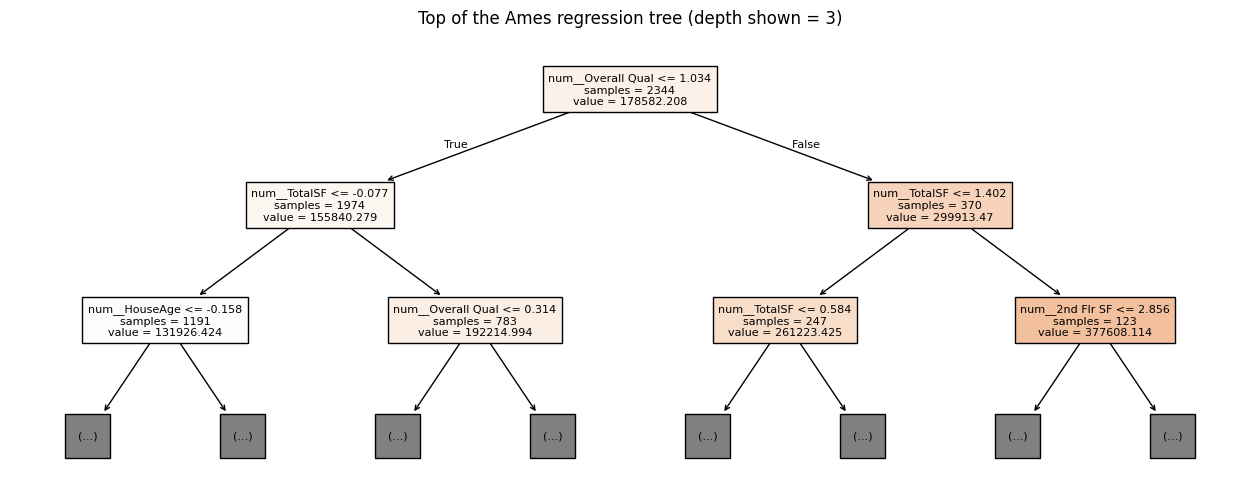

In [8]:
# Visualise the top of the tree: these ARE the if/then rules it learned.
plt.figure(figsize=(16, 6))
feat_names = tree.named_steps['pre'].get_feature_names_out()
plot_tree(tree.named_steps['model'], feature_names=feat_names,
          filled=True, fontsize=8, max_depth=2, impurity=False)
plt.title('Top of the Ames regression tree (depth shown = 3)')
plt.show()

**How to read a tree diagram.** Read top to bottom, following the arrows.

- **Each box is a question** about one feature, like `TotalSF <= 0.31` (a standardised value,
  since our pipeline scaled the numeric columns). **Left branch = yes, right branch = no.**
- **`samples`** is how many training houses reached that box; **`value`** is the average sale
  price of those houses, which is what the model predicts for anything landing there.
- **The colour** encodes the predicted value — darker means more expensive.
- **The very first split is the single most informative question the tree could ask.** Whatever
  feature appears at the root is the strongest predictor in the whole dataset.

This is the property that makes a single tree special: the model *is* the diagram. Nothing is
hidden. Contrast that with the 300-tree forest coming next, which cannot be drawn at all — the
accuracy/interpretability trade-off in one page.

A depth-3 tree is too simple and *underfits*. Its strength appears when we let many trees vote. Let's bring in the ensembles.

**Voting — the simplest ensemble.** Before combining many trees the same way, try the crudest idea that works: train several different model types and average their predictions. A linear model, a k-NN, and a tree each make different *kinds* of mistakes, so averaging cancels part of each. It only helps when the members are comparably good but differently wrong; mix in a much weaker model and the average gets dragged down.


In [9]:
members = {
    'Linear Regression': Pipeline([('pre', make_preprocessor(X)), ('model', LinearRegression())]),
    'k-NN (k=10)':        Pipeline([('pre', make_preprocessor(X)), ('model', KNeighborsRegressor(n_neighbors=10))]),
    'Tree (depth 8)':     Pipeline([('pre', make_preprocessor(X)), ('model', DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE))]),
}
for name, m in members.items():
    m.fit(X_train, y_train)
    print(f'{name:20s} test R2 = {m.score(X_test, y_test):.3f}')

voting = VotingRegressor([(k, v) for k, v in members.items()]).fit(X_train, y_train)
rmse_v, _, r2_v = regression_report(y_test, voting.predict(X_test), label='Voting (3 models):')
log_score(4, 'Ames', 'ensemble', 'Voting', 'RMSE', rmse_v, '3 models, averaged')


Linear Regression    test R2 = 0.891
k-NN (k=10)          test R2 = 0.857
Tree (depth 8)       test R2 = 0.793
Voting (3 models):  RMSE=28,997   MAE=16,114   R2=0.895


/tmp/ipykernel_1424/2990803930.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  board = pd.concat([board, pd.DataFrame([row])], ignore_index=True)


,day,dataset,stage,model,metric,value,notes
0,4,Ames,ensemble,Voting,RMSE,28997.215,"3 models, averaged"


Compare voting against the three members above. Here it edges out even the best individual member (Linear Regression) -- usually it lands somewhere between the weakest and the best, since averaging in a weaker model costs something, but that is not a guarantee. Useful as a cheap robustness trick; it will not always beat your best single model, but it did on this run.


**Bagging (Bootstrap Aggregating).** Instead of varying the model type, keep one model type and vary the data. Draw a **bootstrap sample**: sample rows from the training set *with replacement*, so some rows appear several times and roughly 37 percent do not appear at all. Train a full, unpruned tree on that sample. Repeat many times and average the predictions.

Each tree overfits its own sample in its own random way. Those overfitting mistakes are largely independent, so averaging cancels them out while the real signal, which every sample shares, survives.


In [10]:
bag = Pipeline([
    ('pre', make_preprocessor(X)),
    ('model', BaggingRegressor(estimator=DecisionTreeRegressor(random_state=RANDOM_STATE),
                               n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)),
]).fit(X_train, y_train)

rmse_bag, _, r2_bag = regression_report(y_test, bag.predict(X_test), label='Bagging (100 trees):')
log_score(4, 'Ames', 'ensemble', 'Bagging', 'RMSE', rmse_bag, '100 bootstrap trees, no depth tuning')


Bagging (100 trees):  RMSE=25,468   MAE=15,372   R2=0.919


,day,dataset,stage,model,metric,value,notes
0,4,Ames,ensemble,Voting,RMSE,28997.2150,"3 models, averaged"
1,4,Ames,ensemble,Bagging,RMSE,25467.9791,"100 bootstrap trees, no depth tuning"


None of these 100 trees had their depth tuned, and averaging them still beats the single depth-3 tree we hand-tuned above for readability. That is bagging's whole pitch: turn an unstable, easily overfit model into a stable one just by averaging many of them.


**From plain bagging to Random Forest, plus a first look at boosting.**

- **Random Forest** is bagging **plus feature subsampling**: at every split, each tree may
  only consider a random subset of the features rather than all of them. In plain bagging, if
  one feature is strongly predictive every tree splits on it first, so the trees look alike and
  averaging near-identical models achieves little. Forcing each split to ignore some features
  **de-correlates** the trees, which is why Random Forest usually beats plain bagging.
- **Gradient Boosting** — trees added one at a time, each fitted to the errors of the ones
  before it. Reduces **bias** rather than variance. We come back to boosting in depth in the
  Ensemble Learning lecture.

In [11]:
rf = Pipeline([('pre', make_preprocessor(X)),
               ('model', RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))])
gb = Pipeline([('pre', make_preprocessor(X)),
               ('model', GradientBoostingRegressor(random_state=RANDOM_STATE))])

rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

rmse_rf, _, r2_rf = regression_report(y_test, rf.predict(X_test), label='RandomForest :')
rmse_gb, _, r2_gb = regression_report(y_test, gb.predict(X_test), label='GradBoosting :')

RandomForest :  RMSE=25,439   MAE=15,469   R2=0.919
GradBoosting :  RMSE=23,178   MAE=14,803   R2=0.933


In [12]:
log_score(4, 'Ames', 'ensemble', 'RandomForest', 'RMSE', rmse_rf, '300 trees, same features')
log_score(4, 'Ames', 'ensemble', 'RandomForest', 'R2', r2_rf, '300 trees, same features')
log_score(4, 'Ames', 'ensemble', 'GradientBoosting', 'RMSE', rmse_gb, 'default params')
log_score(4, 'Ames', 'ensemble', 'GradientBoosting', 'R2', r2_gb, 'default params')

,day,dataset,stage,model,metric,value,notes
0,4,Ames,ensemble,Voting,RMSE,28997.2150,"3 models, averaged"
1,4,Ames,ensemble,Bagging,RMSE,25467.9791,"100 bootstrap trees, no depth tuning"
2,4,Ames,ensemble,RandomForest,RMSE,25438.5620,"300 trees, same features"
3,4,Ames,ensemble,RandomForest,R2,0.9193,"300 trees, same features"
4,4,Ames,ensemble,GradientBoosting,RMSE,23178.1160,default params
5,4,Ames,ensemble,GradientBoosting,R2,0.9330,default params


In [13]:
print('The whole Ames climb, baseline -> engineered linear -> ensembles:')
show_scoreboard(dataset='Ames', metric='RMSE')

The whole Ames climb, baseline -> engineered linear -> ensembles:


,day,dataset,stage,model,metric,value,notes
0,4,Ames,ensemble,Voting,RMSE,28997.2150,"3 models, averaged"
1,4,Ames,ensemble,Bagging,RMSE,25467.9791,"100 bootstrap trees, no depth tuning"
2,4,Ames,ensemble,RandomForest,RMSE,25438.5620,"300 trees, same features"
3,4,Ames,ensemble,GradientBoosting,RMSE,23178.1160,default params


The engineered linear model reached RMSE of around 22K. Gradient Boosting on the same features lands around 23k and Random Forest around 25k -- both still a bit worse here, though Gradient Boosting comes close. The lesson: once thorough feature engineering has encoded the structure, a straight-line model can be hard to beat, and a fancier model isn't automatically better. On other data trees would pull ahead, the point is you test the switch, you don't assume it.

**Inside the forest: out-of-bag scoring.** Each bootstrap sample leaves out about 37 percent of the rows. Those out-of-bag rows are unseen by that particular tree, so they can score it, giving a validation estimate without touching the test set or running cross-validation.


In [14]:
rf_oob = Pipeline([
    ('pre', make_preprocessor(X)),
    ('model', RandomForestRegressor(n_estimators=300, oob_score=True, random_state=RANDOM_STATE, n_jobs=-1)),
]).fit(X_train, y_train)

print('Out-of-bag R2:', round(rf_oob.named_steps['model'].oob_score_, 3), '  <- computed from training data alone')
print('Test R2      :', round(rf_oob.score(X_test, y_test), 3), '  <- our held-out set')


Out-of-bag R2: 0.888   <- computed from training data alone
Test R2      : 0.919   <- our held-out set


**Watching de-correlation directly.** `max_features` controls how many features each split may consider. `1.0` gives plain bagging (all features available); smaller values force more diversity between trees.


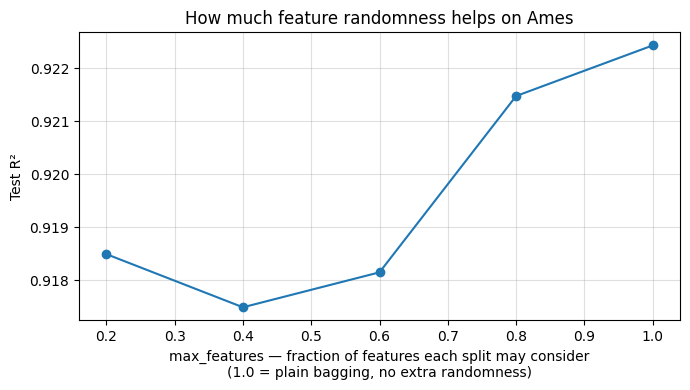

,max_features,test_r2
0,0.2,0.918
1,0.4,0.917
2,0.6,0.918
3,0.8,0.921
4,1.0,0.922


In [15]:
mf_rows = []
for mf in [0.2, 0.4, 0.6, 0.8, 1.0]:
    m = Pipeline([
        ('pre', make_preprocessor(X)),
        ('model', RandomForestRegressor(n_estimators=100, max_features=mf, random_state=RANDOM_STATE, n_jobs=-1)),
    ]).fit(X_train, y_train)
    mf_rows.append({'max_features': mf, 'test_r2': m.score(X_test, y_test)})

mf_df = pd.DataFrame(mf_rows)
plt.figure(figsize=(7, 4))
plt.plot(mf_df['max_features'], mf_df['test_r2'], 'o-')
plt.title('How much feature randomness helps on Ames')
plt.xlabel('max_features — fraction of features each split may consider\n(1.0 = plain bagging, no extra randomness)')
plt.ylabel('Test R²')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()
mf_df.round(3)


If the curve peaks below 1.0, de-correlation is paying off on this dataset. If it peaks at 1.0, no single feature was dominating enough for the extra randomness to matter, which is itself useful to know.


**What drives price? Feature importances from the Random Forest.** The same trick works for regression: a tree ensemble keeps a running tally of how much each feature reduced error across every split in every tree, giving a ranking of what the model actually leans on.


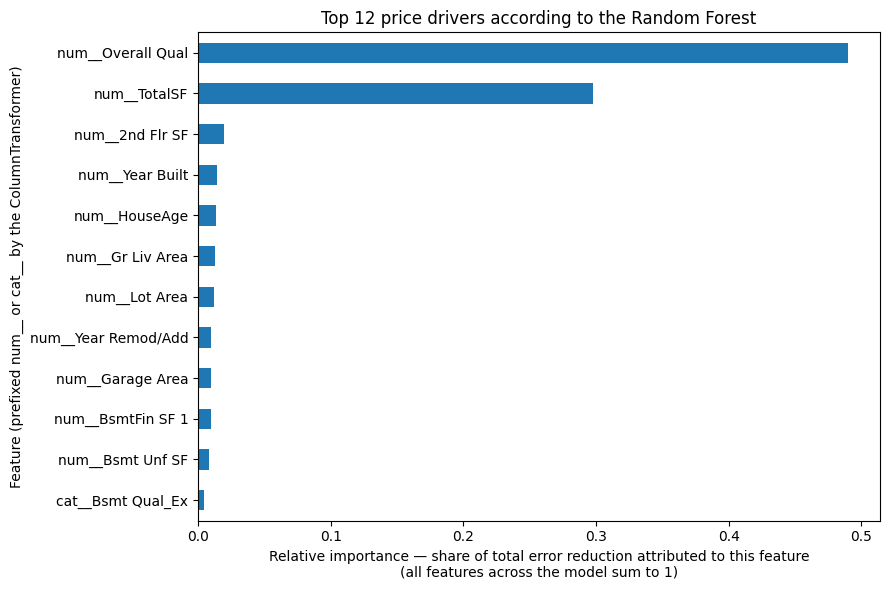

In [16]:
rf_model = rf.named_steps['model']
names = rf.named_steps['pre'].get_feature_names_out()
imp = pd.Series(rf_model.feature_importances_, index=names).sort_values(ascending=False).head(12)

imp[::-1].plot(kind='barh', figsize=(9, 6))
plt.title('Top 12 price drivers according to the Random Forest')
plt.xlabel('Relative importance — share of total error reduction attributed to this feature\n(all features across the model sum to 1)')
plt.ylabel('Feature (prefixed num__ or cat__ by the ColumnTransformer)')
plt.tight_layout()
plt.show()


**How to read this chart.** Longer bar = the forest relied on that feature more when splitting.
The `num__` and `cat__` prefixes are added by the `ColumnTransformer` to show which path each
feature came down.

Expect `Overall Qual`, the size columns (`TotalSF`, `Gr Liv Area`), and the age-related columns near
the top -- which matches what anyone who has house-hunted would tell you, and is a good sign the
model is learning something real rather than an artefact.

**Two caveats worth stating.** First, importance is **not causation**: it says the model used the
feature, not that the feature causes the price. Second, one-hot encoding **splits a column's
importance across its levels**, so a categorical variable with many categories looks less
important than it is. Add the levels back together before comparing it against a numeric column.


## 2. EXERCISE

1. **Tame a tree.** Grow a single `DecisionTreeRegressor` on Ames with `max_depth=None`, then again with `max_depth=4`. Compare train vs test R² for each. Which overfits more, and why?
2. **Tune the forest.** Try `n_estimators` in [50, 300, 600] for the Ames Random Forest. Does more trees keep helping, or does it flatten out?
3. **Reflection (markdown).** Explain in two sentences *why* a tree-based model could break the ceiling that the linear model could not, using the words "interaction" and "threshold".


In [17]:
# TODO: your tree-depth and n_estimators experiments; log_score(stage='exercise')


_Your written reflection here._